# STM Simulator Demo
This notebook exercises the core routines: scene generation, STM solving, noise, and labels.
It uses a full scene with adatoms, vacancies, molecules, and optional steps.

All lengths are in Angstroms (?).


In [1]:
import sys
from pathlib import Path

repo_root = Path(r'C:\Users\phili\Documents\Github\stm-topography-sim')

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(repo_root))
from stm_sim.config import SimulationConfig
from stm_sim.simulator import build_scene_from_config
from stm_sim.utils import ensure_rng, grid_from_bbox
from stm_sim.geometry import plot_scene_top_view
from stm_sim.stm import solve_constant_current
from stm_sim.noise import apply_noise
from stm_sim.labels import generate_mask

%reload_ext autoreload
%autoreload 2


In [7]:
# Full scene configuration
cfg = SimulationConfig(seed=50)
cfg.surface.size_angstrom = (70.0, 70.0)  # 5 nm in ?
cfg.features.step_probability = 1
cfg.features.step_height_layers = 1

cfg.features.adatom_count = (3, 6)
cfg.features.vacancy_count = (2, 4)
cfg.features.molecule_count = (1, 1)
# Toggle molecule type: 'FePc' or 'YPc2'
cfg.features.molecule_name = 'YPc2'
cfg.noise.tip_sigma = (2.0, 2.0)
cfg.features.molecule_z_scale = 1/10

rng = ensure_rng(cfg.seed)
scene = build_scene_from_config(cfg, rng)
base_bbox = scene.metadata.get('surface_bbox', scene.bbox)

print('Surface atoms:', int((scene.types == 'surface').sum()))
print('Adatoms:', int((scene.types == 'adatom').sum()))
print('Molecule atoms:', int((scene.types == 'molecule').sum()))
print('Vacancies:', scene.vacancies.shape[0])
print('Step edges:', scene.step_edges)


Surface atoms: 623
Adatoms: 6
Molecule atoms: 112
Vacancies: 2
Step edges: [{'axis': 'angle', 'position': None, 'height': 2.045, 'normal': [-0.8665527107329893, 0.4990855633268789], 'point': [3.029830318862963, 32.56671398114105], 'angle_deg': 150.06048022504484}]


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Atomic Positions (Top View)'}, xlabel='x (Å)', ylabel='y (Å)'>)

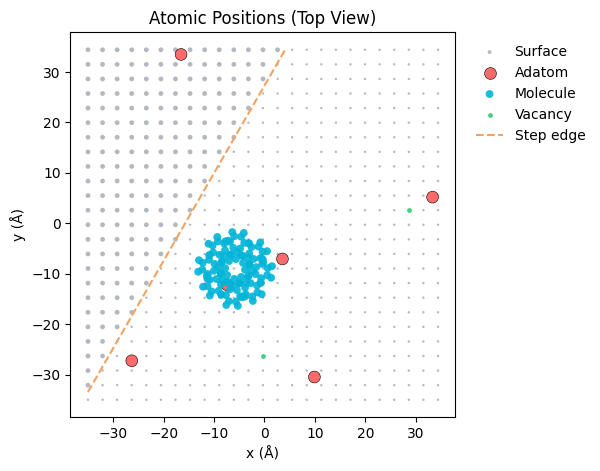

In [8]:
# Scene view (top-down)
plot_scene_top_view(scene)


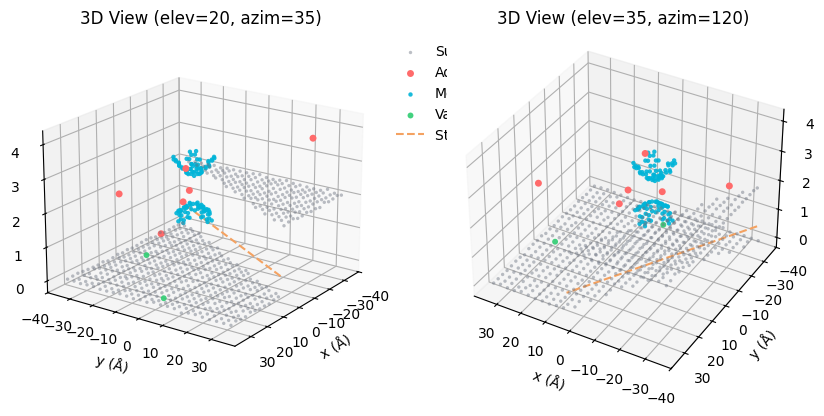

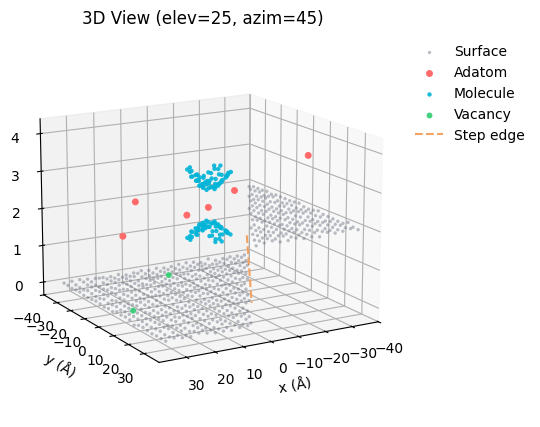

In [9]:
from stm_sim.geometry import plot_scene_3d

plot_scene_3d(scene, views=[(20, 35), (35, 120)])
# or change angles interactively:
fig, axes = plot_scene_3d(scene, zlim=(-5, 5))
axes[0].view_init(elev=15, azim=60)


In [10]:
# Compute constant-current height (raw) and noisy image
x, y = grid_from_bbox(base_bbox, cfg.image.pixels)
setpoint = np.mean(cfg.stm.setpoint_range)
raw_height = solve_constant_current(scene, x, y, setpoint, cfg.ldos, cfg.stm)
base_bbox = scene.metadata.get('surface_bbox', scene.bbox)
# Convert blur sigma (?) to pixels using grid spacing
nx = cfg.image.pixels[1]
ny = cfg.image.pixels[0]
xmin, xmax = scene.bbox[0]
ymin, ymax = scene.bbox[1]
dx = (xmax - xmin) / max(1, nx - 1)
dy = (ymax - ymin) / max(1, ny - 1)
image = apply_noise(raw_height, cfg.noise, rng, pixel_size=(dx, dy))
mask = generate_mask(scene, cfg.image.pixels, cfg.labels, bbox=base_bbox)


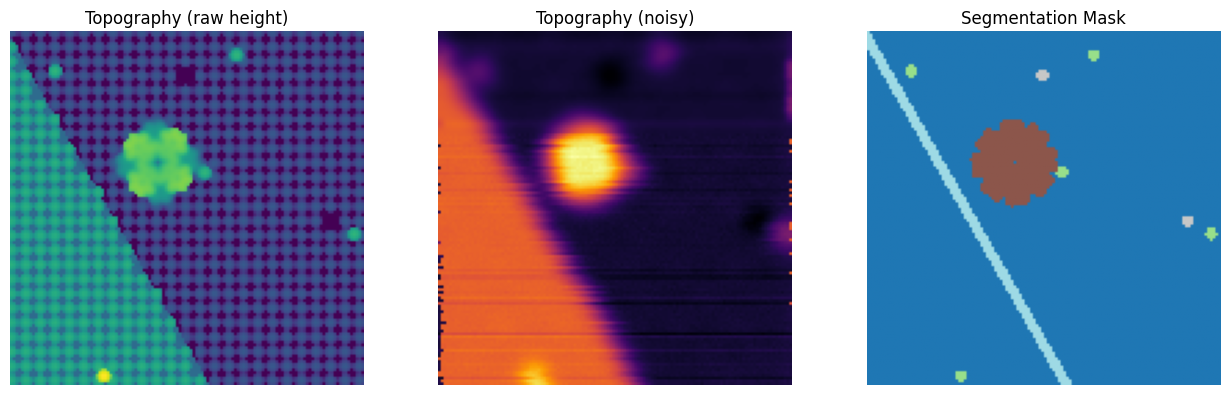

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(raw_height, cmap='viridis')
axes[0].set_title('Topography (raw height)')
axes[0].axis('off')

axes[1].imshow(image, cmap='inferno')
axes[1].set_title('Topography (noisy)')
axes[1].axis('off')

axes[2].imshow(mask, cmap='tab20')
axes[2].set_title('Segmentation Mask')
axes[2].axis('off')

plt.tight_layout()
